# Dataset Check & Exploration: Kermany Chest X-Rays

**Dataset.** Paediatric chest X-rays (1–5 years old), Guangzhou Women and Children's Medical Center, distributed on Kaggle by Paul Mooney (original data: Kermany et al., 2018). ≈5.8k images, anterior-posterior view.

**Why this notebook.** Before training anything, we *understand* the data: folder structure, class balance, the two labelling levels, image sizes, and what the three diagnostic categories actually look like.

**Two labelling levels used in this project:**
- **Binary**: `NORMAL` vs `PNEUMONIA` (the folder layout). Used in notebook 01.
- **Three-class**: `NORMAL` / `BACTERIA` / `VIRUS`. The pneumonia sub-type is encoded in the **filename** (`*_bacteria_*` / `*_virus_*`), not in a separate folder. Used in notebook 02.

**What we check:**
1. Folder structure resolves and class counts (binary **and** bacteria/virus breakdown).
2. Class **imbalance** that motivates class weighting later.
3. Two data caveats that shaped our methodology: the tiny official validation split, and multiple X-rays per patient.
4. Sample images for each of the three categories.
5. Image-size statistics (justifies the 224×224 resize).

In [45]:
from __future__ import annotations
import random
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

SEED = 7
random.seed(SEED)

DATASET_ROOT = Path("../data/chest_xray")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT.resolve()}")

DATASET_ROOT.resolve()


WindowsPath('C:/Users/Carolina/OneDrive - 4sb643/Ambiente de Trabalho/UA/CAA/Project/data/chest_xray')

## 1. Verify folder structure and class counts

This cell checks whether the expected split/class folders exist and counts how many images are inside each one.


In [46]:
def list_image_paths(split: str, class_name: str) -> list[Path]:
    folder = DATASET_ROOT / split / class_name
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder: {folder.resolve()}")
    return sorted(path for path in folder.iterdir() if path.is_file())


records = []
for split in SPLITS:
    for class_name in CLASSES:
        image_paths = list_image_paths(split, class_name)
        records.append(
            {
                "split": split,
                "class": class_name,
                "count": len(image_paths),
            }
        )

count_df = pd.DataFrame(records)
count_pivot = count_df.pivot(index="split", columns="class", values="count")

print(count_df.to_string(index=False))
print()
print(count_pivot.to_string())


split     class  count
train    NORMAL   1341
train PNEUMONIA   3875
  val    NORMAL      8
  val PNEUMONIA      8
 test    NORMAL    234
 test PNEUMONIA    390

class  NORMAL  PNEUMONIA
split                   
test      234        390
train    1341       3875
val         8          8


### 1b. Three-class breakdown (bacteria vs virus) and imbalance

The `PNEUMONIA` folder mixes two sub-types. We split it by filename (`_bacteria_` / `_virus_`) to get the three-class counts. This is exactly how the three-class task derives its labels.

In [47]:
def three_class_of(path: Path, class_name: str) -> str:
    """NORMAL folder -> NORMAL; PNEUMONIA -> BACTERIA/VIRUS from the filename."""
    if class_name == "NORMAL":
        return "NORMAL"
    name = path.name.lower()
    if "_bacteria_" in name or name.startswith("bacteria"):
        return "BACTERIA"
    if "_virus_" in name or name.startswith("virus"):
        return "VIRUS"
    return "BACTERIA"  # fallback (ambiguous pneumonia)

three_records = []
for split in SPLITS:
    counts3 = {"NORMAL": 0, "BACTERIA": 0, "VIRUS": 0}
    for class_name in CLASSES:
        for p in list_image_paths(split, class_name):
            counts3[three_class_of(p, class_name)] += 1
    three_records.append({"split": split, **counts3})

three_df = pd.DataFrame(three_records).set_index("split")
three_df["TOTAL"] = three_df.sum(axis=1)
print("Three-class counts per split")
print(three_df.to_string())

# Imbalance ratio on the training set
tr = three_df.loc["train"]
print(f"\nTrain imbalance: BACTERIA is {tr['BACTERIA'] / tr['VIRUS']:.1f}x the VIRUS count "
      f"and {tr['BACTERIA'] / tr['NORMAL']:.1f}x the NORMAL count.")
print("-> motivates inverse-frequency class weights in the three-class task.")

Three-class counts per split
       NORMAL  BACTERIA  VIRUS  TOTAL
split                                
train    1341      2530   1345   5216
val         8         8      0     16
test      234       242    148    624

Train imbalance: BACTERIA is 1.9x the VIRUS count and 1.9x the NORMAL count.
-> motivates inverse-frequency class weights in the three-class task.


### 1c. Two data caveats that shaped our methodology

The exploration surfaces two issues that are easy to miss but matter a lot:

1. **The official validation split is tiny** (16 images) and has **no viral pneumonia**: useless for reliable model selection.
2. **Multiple X-rays per patient.** Pneumonia filenames are `personNNN_...`, and many patients contribute several images. An image-level train/val split would put the *same patient* on both sides (data leakage) and inflate validation scores.

Both are why notebook 02 uses a **patient-aware stratified** validation split instead of the official `val/` folder.

In [48]:
import re

# Caveat 1: tiny validation split
val_total = int(three_df.loc["val", ["NORMAL", "BACTERIA", "VIRUS"]].sum())
print(f"Caveat 1 - official val split: {val_total} images total, "
      f"VIRUS count = {int(three_df.loc['val', 'VIRUS'])} (cannot validate the viral class).")

# Caveat 2: multiple images per patient (train pneumonia)
patient_ids = []
for p in list_image_paths("train", "PNEUMONIA"):
    m = re.match(r"(person\d+)", p.name.lower())
    if m:
        patient_ids.append(m.group(1))

imgs_per_patient = Counter(patient_ids)
n_patients = len(imgs_per_patient)
n_images = len(patient_ids)
multi = sum(1 for c in imgs_per_patient.values() if c > 1)
print(f"\nCaveat 2 - train PNEUMONIA: {n_images} images from {n_patients} unique patients "
      f"(avg {n_images / n_patients:.1f} images/patient, max {max(imgs_per_patient.values())}).")
print(f"  {multi} patients ({100 * multi / n_patients:.0f}%) have more than one image "
      f"-> an image-level split would leak patients across train/val.")

Caveat 1 - official val split: 16 images total, VIRUS count = 0 (cannot validate the viral class).

Caveat 2 - train PNEUMONIA: 3875 images from 1635 unique patients (avg 2.4 images/patient, max 30).
  1005 patients (61%) have more than one image -> an image-level split would leak patients across train/val.


## 2. Plot class distribution

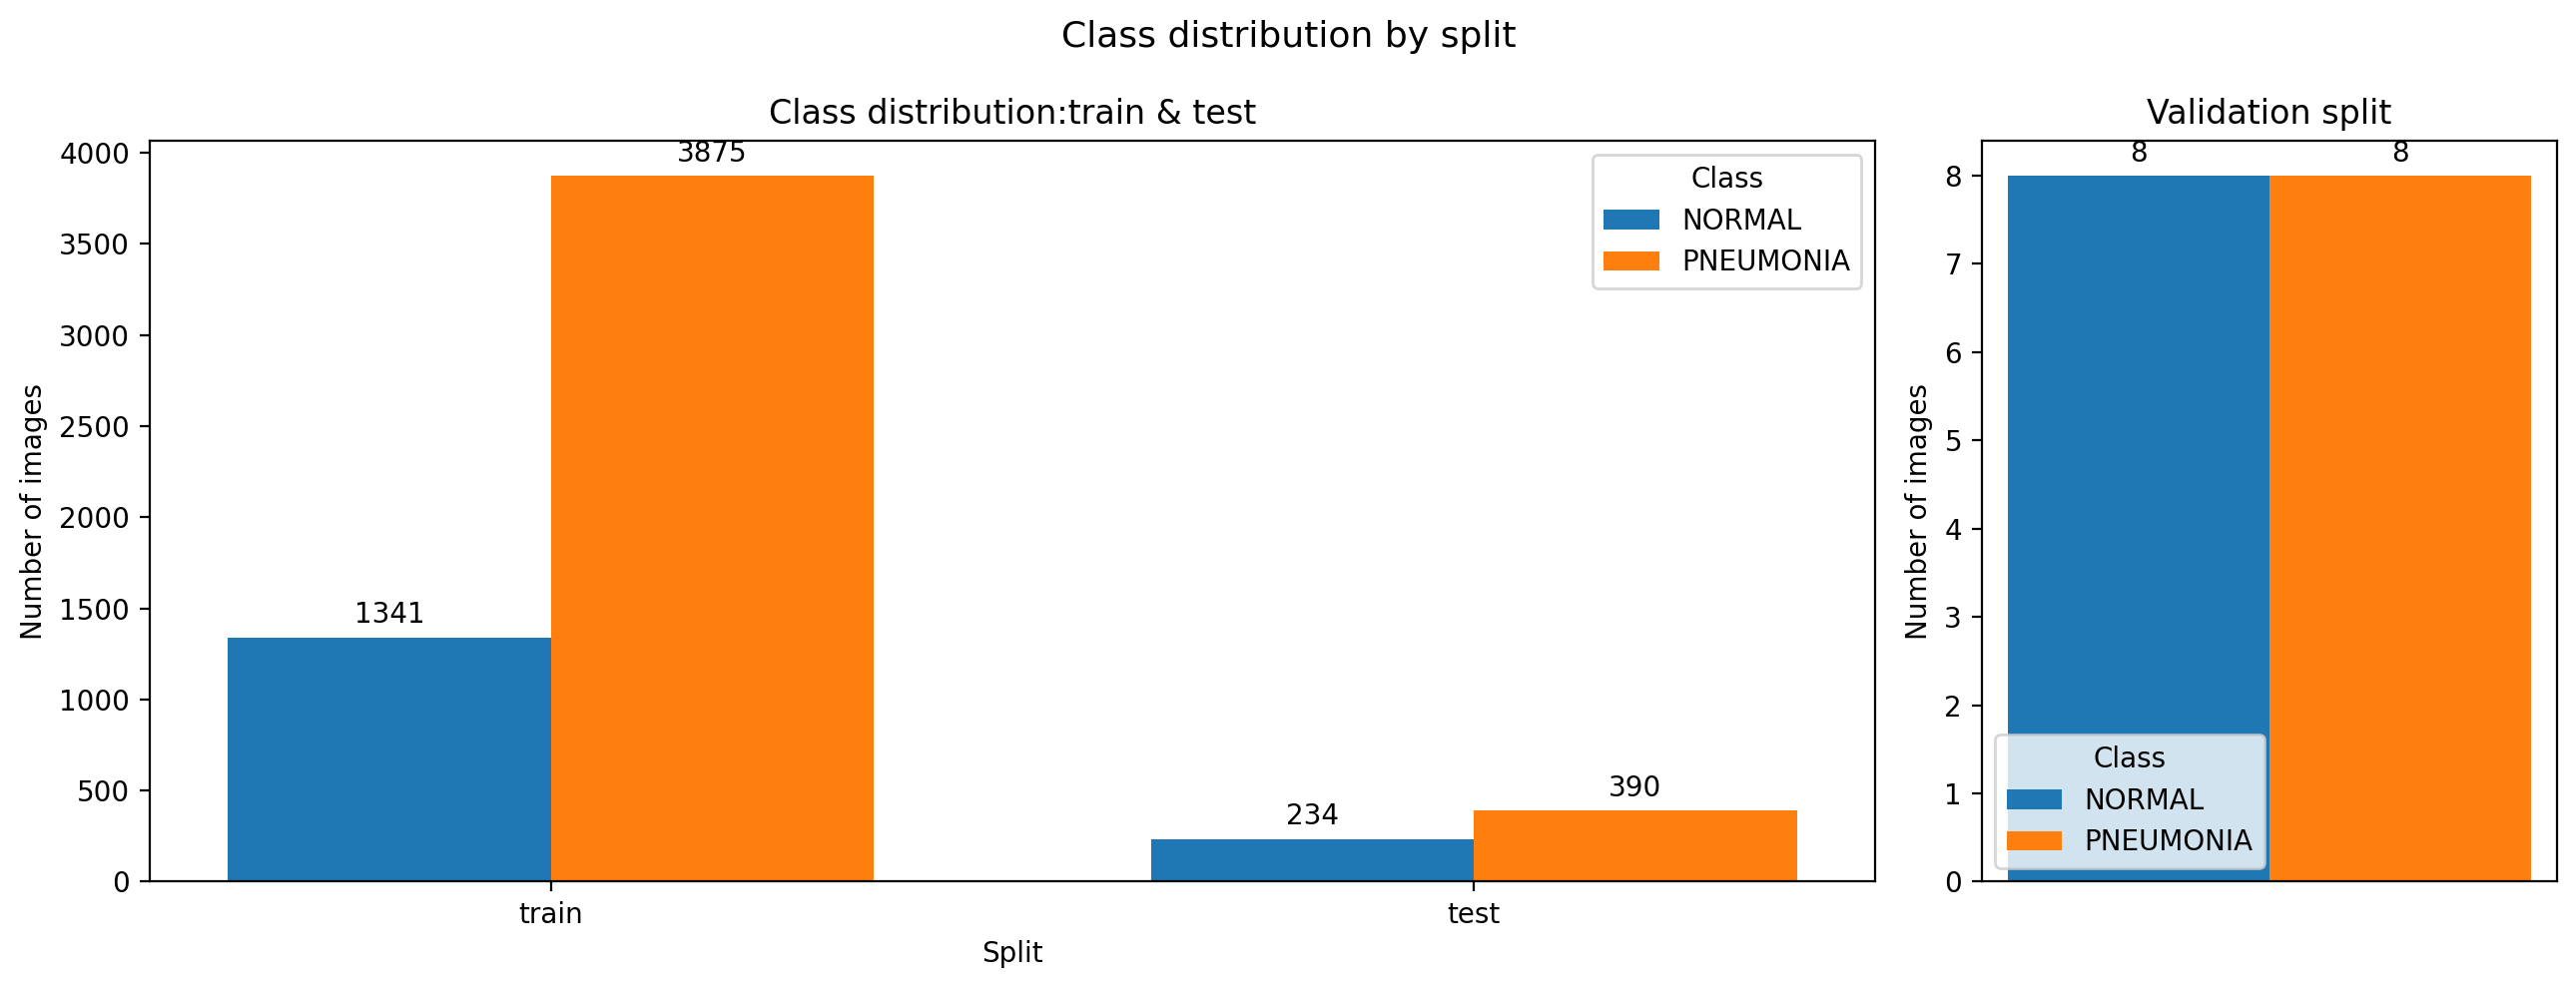

Saved figure to: ..\results\figures\class_distribution.png


In [49]:
import sys
sys.path.insert(0, "../src")
from pneumonia_classifier.visualization.plots import plot_class_distribution
from IPython.display import Image as IPImage, display

counts = {
    split: {cls: int(count_pivot.loc[split, cls]) for cls in CLASSES}
    for split in SPLITS
}
figure_path = plot_class_distribution(counts, output_dir=FIGURES_DIR)
display(IPImage(str(figure_path)))
print(f"Saved figure to: {figure_path}")


## 3. Sample images: the three categories

A few training examples per category, so we can see what the model is asked to distinguish. Following Kermany et al. (Fig. S6):

- **NORMAL**: clear lungs, no abnormal opacification.
- **BACTERIA**: typically a *focal lobar consolidation* (a dense, localised white patch).
- **VIRUS**: a more diffuse, *bilateral interstitial* pattern (subtle, spread across both lungs).

The bacterial/viral visual difference is what makes the three-class task hard: the viral pattern is diffuse and overlaps with both normal lungs and early bacterial cases.

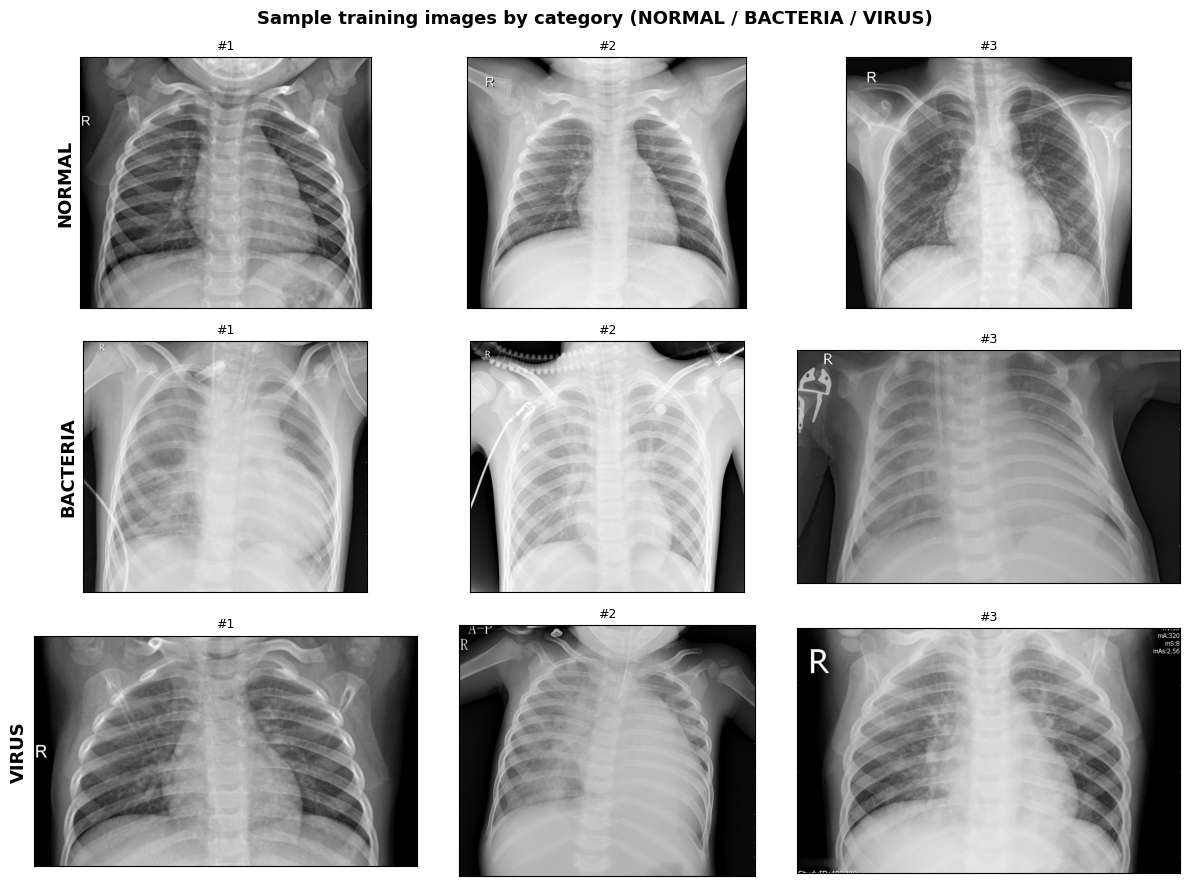

Saved figure to: ..\results\figures\sample_images_three_class.png


In [52]:
THREE_CLASSES = ["NORMAL", "BACTERIA", "VIRUS"]
samples_per_class = 3

# Group training images by three-class label
paths_by_3class = {c: [] for c in THREE_CLASSES}
for class_name in CLASSES:
    for p in list_image_paths("train", class_name):
        paths_by_3class[three_class_of(p, class_name)].append(p)

rng = random.Random(SEED)  # deterministic selection
fig, axes = plt.subplots(len(THREE_CLASSES), samples_per_class, figsize=(12, 9))

for row, cls in enumerate(THREE_CLASSES):
    chosen = rng.sample(paths_by_3class[cls], k=min(samples_per_class, len(paths_by_3class[cls])))
    for col in range(samples_per_class):
        ax = axes[row, col]
        if col < len(chosen):
            with Image.open(chosen[col]) as image:
                ax.imshow(image, cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        # Row label (class name) on the first column; image index as title
        if col == 0:
            ax.set_ylabel(cls, fontsize=13, fontweight="bold")
        ax.set_title(f"#{col + 1}", fontsize=9)

plt.suptitle("Sample training images by category (NORMAL / BACTERIA / VIRUS)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out = FIGURES_DIR / "sample_images_three_class.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out}")

## 4. Inspect image sizes

This cell checks whether image resolutions are varied and gives basic statistics before resizing is introduced in the training pipeline.


In [53]:
all_image_paths = []
for split in SPLITS:
    for class_name in CLASSES:
        all_image_paths.extend(list_image_paths(split, class_name))

size_records = []
for path in all_image_paths:
    with Image.open(path) as image:
        width, height = image.size
    size_records.append({"width": width, "height": height})

size_df = pd.DataFrame(size_records)
print(size_df.describe().to_string())

resolution_counts = Counter((item["width"], item["height"]) for item in size_records)
common_resolutions = pd.DataFrame(
    [
        {"resolution": f"{width}x{height}", "count": count}
        for (width, height), count in resolution_counts.most_common(10)
    ]
)
print()
print(common_resolutions.to_string(index=False))


             width       height
count  5856.000000  5856.000000
mean   1327.880806   970.689037
std     363.500922   383.392117
min     384.000000   127.000000
25%    1056.000000   688.000000
50%    1281.000000   888.000000
75%    1560.000000  1187.000000
max    2916.000000  2713.000000

resolution  count
  1072x648      7
  1008x704      7
  1216x872      6
  1080x728      6
   992x592      6
   992x608      6
  1304x968      5
  1088x712      5
  1008x680      5
   976x672      5
